## 1. Visualizing Model Fit and Optimization (Lecture 7D/8A)

In Lecture 7D, you saw that least squares fits a model by choosing parameter values that minimize prediction error. In Lecture 8A, we extended that idea by viewing learning as an optimization problem and discussing convex and non-convex functions.

Use the dataset below:

| x | y |
|---|---|
| 1 | 2 |
| 2 | 3 |
| 3 | 5 |
| 4 | 4 |
| 5 | 6 |

Consider the linear model $\hat{y} = wx + b$.

Evaluate the model for the following three parameter choices:

- $w = 0.5$, $b = 1$
- $w = 1$, $b = 1$
- $w = 1.2$, $b = 0.5$

### (a) For each parameter choice, compute:

- the predicted value $\hat{y}$ for each data point
- the squared error $(y - \hat{y})^2$ for each data point
- the total squared error

### (b) Draw a simple sketch of the 5 data points on an $x$-$y$ plane.

### (c) On the same sketch, draw the three candidate lines corresponding to the three parameter choices.

### (d) Based on your calculations and sketch,

- Identify which line gives the smallest total squared error.
- Briefly explain why least squares can be viewed as an optimization problem.
- Briefly explain why this problem is easier to reason about when the total squared error function is convex, meaning the error surface has a bowl-shaped form with a clear minimum.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 3, 5, 4, 6], dtype=float)

candidates = {
    'w = 0.5, b = 1.0': (0.5, 1.0),
    'w = 1.0, b = 1.0': (1.0, 1.0),
    'w = 1.2, b = 0.5': (1.2, 0.5),
}

results = {}
for label, (w, b) in candidates.items():
    y_hat = w * x + b
    squared_error = (y - y_hat) ** 2
    results[label] = {
        'w': w,
        'b': b,
        'y_hat': y_hat,
        'squared_error': squared_error,
        'total_squared_error': squared_error.sum(),
    }

for label, result in results.items():
    print(label)
    print('x   y   y_hat   squared_error')
    for xi, yi, yhi, sei in zip(x, y, result['y_hat'], result['squared_error']):
        print(f'{int(xi):<2}    {int(yi):<2}    {yhi:>5.2f}     {sei:>5.2f}')
    print(f"Total squared error: {result['total_squared_error']:.2f}")
    print('-' * 42)

best_label = min(results, key=lambda key: results[key]['total_squared_error'])
print(f'Smallest total squared error: {best_label}')


w = 0.5, b = 1.0
x   y   y_hat   squared_error
1   2    1.50       0.25
2   3    2.00       1.00
3   5    2.50       6.25
4   4    3.00       1.00
5   6    3.50       6.25
Total squared error: 14.75
------------------------------------------
w = 1.0, b = 1.0
x   y   y_hat   squared_error
1   2    2.00       0.00
2   3    3.00       0.00
3   5    4.00       1.00
4   4    5.00       1.00
5   6    6.00       0.00
Total squared error: 2.00
------------------------------------------
w = 1.2, b = 0.5
x   y   y_hat   squared_error
1   2    1.70       0.09
2   3    2.90       0.01
3   5    4.10       0.81
4   4    5.30       1.69
5   6    6.50       0.25
Total squared error: 2.85
------------------------------------------
Smallest total squared error: w = 1.0, b = 1.0


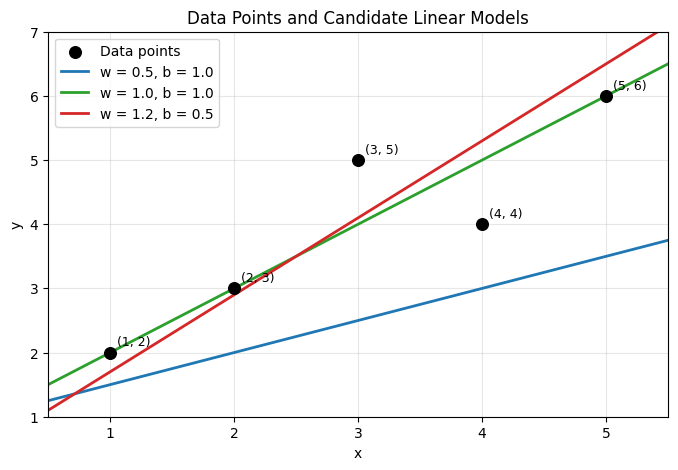

In [ ]:
x_line = np.linspace(0.5, 5.5, 200)
colors = ['tab:blue', 'tab:green', 'tab:red']

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='black', s=70, label='Data points', zorder=3)

for (label, (w, b)), color in zip(candidates.items(), colors):
    plt.plot(x_line, w * x_line + b, color=color, linewidth=2, label=label)

for xi, yi in zip(x, y):
    plt.annotate(f'({int(xi)}, {int(yi)})', (xi, yi), textcoords='offset points', xytext=(5, 5), fontsize=9)

plt.title('Data Points and Candidate Linear Models')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0.5, 5.5)
plt.ylim(1, 7)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


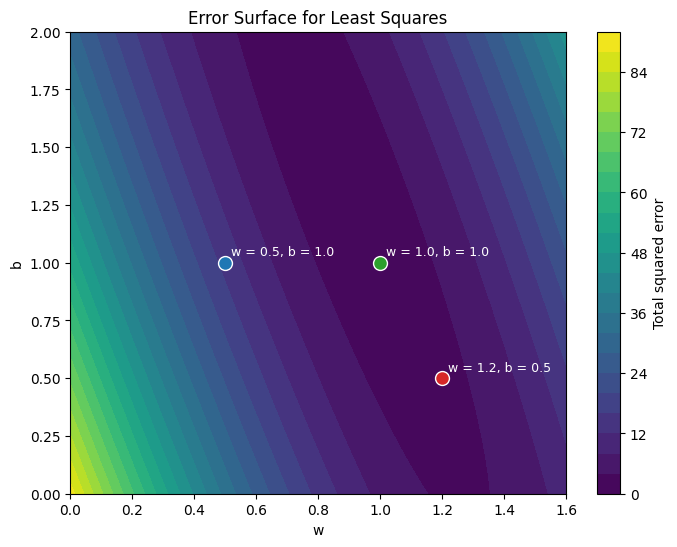

In [ ]:
w_values = np.linspace(0.0, 1.6, 300)
b_values = np.linspace(0.0, 2.0, 300)
W, B = np.meshgrid(w_values, b_values)
total_squared_error = np.zeros_like(W)

for xi, yi in zip(x, y):
    total_squared_error += (yi - (W * xi + B)) ** 2

plt.figure(figsize=(8, 6))
contours = plt.contourf(W, B, total_squared_error, levels=25, cmap='viridis')
plt.colorbar(contours, label='Total squared error')

for (label, (w, b)), color in zip(candidates.items(), colors):
    plt.scatter(w, b, color=color, edgecolor='white', s=100)
    plt.text(w + 0.02, b + 0.03, label, color='white', fontsize=9)

plt.title('Error Surface for Least Squares')
plt.xlabel('w')
plt.ylabel('b')
plt.show()


The line with the smallest total squared error is **$w=1$, $b=1$**, with a total squared error of **2.00**. Looking at the graph, this line stays the closest to the overall pattern of the points. By comparison, **$w=0.5$, $b=1$** is too flat, so it tends to underestimate the higher **$y$** values. The line **$w=1.2$, $b=0.5$** is a better fit overall, but it starts to overshoot some of the points as **$x$** gets larger.

Least squares is considered an optimization problem because we are testing different values of **$(w, b)$** and choosing the combination that makes the total squared error as small as possible. In other words, the model is evaluated using an objective function, and learning happens by minimizing that function.

This is easier to understand when the error function is convex because the graph has one clear bowl-shaped minimum. That means if we move downhill along the error surface, we are moving toward the best solution instead of getting stuck in different local minimum points.


## 2. Comparing Optimization Updates (Lecture 8B/8C)

Consider the one-dimensional objective function $f(w) = (w - 3)^2$.

Its gradient is $f'(w) = 2(w - 3)$.

Suppose the initial parameter value is $w_0 = 0$.

### (a) Basic Gradient Descent

Using learning rate $\alpha = 0.2$, compute the first three updates of gradient descent:

$w_{t+1} = w_t - \alpha f'(w_t)$

For each step, report:

- the current value of $w_t$
- the gradient $f'(w_t)$
- the updated value $w_{t+1}$

### (b) Adaptive-Style Update

Now, consider the following simplified adaptive update rule:

$w_{t+1} = w_t - \frac{\alpha}{\sqrt{g_t^2 + \epsilon}} g_t$

where

- $g_t = f'(w_t)$
- $\alpha = 0.2$
- $\epsilon = 10^{-8}$

Again compute the first three updates starting from $w_0 = 0$.

### (c) Compare the behaviors

Briefly answer:

- Between basic gradient descent and the adaptive-style update, which method changes $w$ by a larger amount in this example?
- Which method is less sensitive to gradient magnitude?
- What does this suggest about why different optimizers may behave differently during training, when adjusting model parameters to reduce error?

In [5]:
def objective_function(weight):
    return (weight - 3) ** 2

def gradient(weight):
    return 2 * (weight - 3)

learning_rate = 0.2
epsilon = 1e-8
initial_weight = 0.0
num_steps = 3

gradient_descent_results = []
current_weight = initial_weight

for step in range(num_steps):
    current_gradient = gradient(current_weight)
    updated_weight = current_weight - learning_rate * current_gradient
    gradient_descent_results.append((step, current_weight, current_gradient, updated_weight))
    current_weight = updated_weight

adaptive_update_results = []
current_weight = initial_weight

for step in range(num_steps):
    current_gradient = gradient(current_weight)
    updated_weight = current_weight - (
        learning_rate / ((current_gradient ** 2 + epsilon) ** 0.5)
    ) * current_gradient
    adaptive_update_results.append((step, current_weight, current_gradient, updated_weight))
    current_weight = updated_weight

print("Basic Gradient Descent")
print("step   current_weight   gradient   updated_weight")
for step, current_weight, current_gradient, updated_weight in gradient_descent_results:
    print(f"{step}      {current_weight:.4f}          {current_gradient:.4f}     {updated_weight:.4f}")

print("\nAdaptive-Style Update")
print("step   current_weight   gradient   updated_weight")
for step, current_weight, current_gradient, updated_weight in adaptive_update_results:
    print(f"{step}      {current_weight:.4f}          {current_gradient:.4f}     {updated_weight:.4f}")


Basic Gradient Descent
step   current_weight   gradient   updated_weight
0      0.0000          -6.0000     1.2000
1      1.2000          -3.6000     1.9200
2      1.9200          -2.1600     2.3520

Adaptive-Style Update
step   current_weight   gradient   updated_weight
0      0.0000          -6.0000     0.2000
1      0.2000          -5.6000     0.4000
2      0.4000          -5.2000     0.6000


For basic gradient descent, the updates move pretty quickly at the beginning because the gradient is large when starting at $w_0 = 0$. The first three updates are:

- $w_1 = 1.2$
- $w_2 = 1.92$
- $w_3 = 2.352$

For the adaptive-style update, the changes are much smaller and more uniform. The first three updates are approximately:

- $w_1 = 0.2$
- $w_2 = 0.4$
- $w_3 = 0.6$

In this example, basic gradient descent changes $w$ by a larger amount. Its step size depends directly on the gradient, so when the gradient is large, the update is also large. The adaptive-style rule is less sensitive to the gradient magnitude because it divides by $\sqrt{g_t^2 + \epsilon}$, which makes the step size stay close to the learning rate.

This shows why different optimizers can behave differently during training. Standard gradient descent can move faster when gradients are large, but adaptive methods can be more controlled and consistent. That can make adaptive methods helpful when gradients vary a lot across steps or parameters.


## 3. Reasoning About Learning Behavior (Lecture 8D)

In this activity, reflect on how gradient-based optimization works in two different learning settings discussed in this lecture.

Consider the following two models:

### Model 1: Logistic Regression

$\hat{y} = \sigma(w^T x + b)$

trained using binary cross-entropy loss, with optional L2 regularization.

### Model 2: A Small Neural Network

$h = \mathrm{ReLU}(W_1 x + b_1), \hat{y} = \sigma(W_2 h + b_2)$

trained using gradient descent.

Answer the following:

### (a) Which model leads to a convex optimization problem, and which leads to a non-convex one?

### (b) Why is optimization generally easier for logistic regression than for neural networks?

### (c) Why does the neural network require backpropagation?

### (d) What role does regularization play in gradient-based learning?

### (e) Suppose the learning rate is set too small or too large. How would training behavior change?

### (f) In 3-4 sentences, explain this statement:

**Learning is an optimization process, but the challenge of that optimization depends strongly on the model structure.**

For logistic regression, the optimization problem is convex, while for a small neural network it is non-convex. Logistic regression has a single overall best solution for the loss function, but a neural network can have many different valleys, flat spots, or local minima because of its layered structure and nonlinear activations.

Optimization is usually easier for logistic regression because the loss surface is more predictable. If we use gradient-based updates, we can be more confident that moving downhill will lead toward the global minimum. With neural networks, the error surface is more complicated, so training can be less stable and more sensitive to things like initialization and learning rate.

The neural network requires backpropagation because there are multiple layers of parameters that all affect the final prediction. Backpropagation applies the chain rule so the model can figure out how each weight and bias contributed to the error and how each one should be updated.

Regularization helps control model complexity during gradient-based learning. It discourages weights from becoming too large, which can reduce overfitting and help the model generalize better to new data.

If the learning rate is too small, training will move very slowly and may take a long time to improve. If the learning rate is too large, the updates can overshoot the minimum and make training unstable or even cause the loss to bounce around instead of decreasing.

Learning is an optimization process because the model is always adjusting its parameters to reduce some loss function. At the same time, how hard that optimization is depends a lot on the structure of the model. Simpler models like logistic regression usually have smoother and easier loss surfaces, while neural networks have more complex landscapes that are harder to navigate. That is why choosing a model also means choosing a different kind of optimization challenge.
